# 46 · autoimmune diseases against healthy children · bulk_RNA_seq

Reads the raw counts of notebook 40 (CANDLE, SAVI, AGS, UAID), notebook 45 (healthy children) and notebook 12
(SLE, GSE232381, the authors' expected counts), and the ComBat-seq counts of notebook 40 for display. Writes
`de_<disease>_vs_<healthy block>.csv` and `top_genes_<disease>_vs_<healthy block>.csv` in
`data/run_artifacts/CANDLE_SAVI/`, and figures to `figures/CANDLE_SAVI/`.

**Objective.** Compare the blood of each autoimmune disease with the blood of healthy children, and the five
diseases together as one autoimmune block, against each of two healthy blocks.

| group | samples | source |
|---|---|---|
| AGS, CANDLE, SAVI, UAID | 160 | internal counts, four facilities (notebook 40) |
| SLE | 25 | GSE232381, lupus nephritis, pediatric-onset cohort; the authors' counts (notebook 12) |
| healthy_under2, healthy_2plus | 43 | GSE69529, healthy children in Mexico; the authors' counts (notebook 45) |

**One fact to keep in mind when reading the results.** The healthy children, the SLE patients and the internal
patients were sequenced in different labs. A gene that differs between healthy children and a disease may
differ because of the disease or because of the lab; the two cannot be told apart statistically, because each
lab holds one kind of sample. Two checks help read the results: the interferon response genes, whose rise in
these diseases is known, and whether a difference from healthy is seen in patients from every facility.

**Method.** limma-voom (Law CW, Chen Y, Shi W, Smyth GK. *Genome Biol* 2014;15:R29) on the raw counts of the
genes common to all three sources, with TMM normalization; the patient as a blocking factor
(`duplicateCorrelation`; Smyth GK, Michaud J, Scott HS. *Bioinformatics* 2005;21:2067-2075), as in notebook
41; batch terms where a batch holds more than one group (below). Top genes: Benjamini-Hochberg adjusted
p < 0.05 and a fold change of at least 2, as in notebook 41.

## Read the three sources

In [1]:
source("../src/paths.R")
suppressMessages({library(limma); library(edgeR); library(ComplexHeatmap); library(circlize)})
x   <- readRDS(art("CANDLE_SAVI", "counts_raw.rds")); s <- readRDS(art("CANDLE_SAVI", "samples.rds"))
hc  <- readRDS(art("CANDLE_SAVI", "healthy_counts.rds")); hs <- readRDS(art("CANDLE_SAVI", "healthy_samples.rds"))
sle <- readRDS(art("GSE232381", "expression.rds"))
c(internal = ncol(x$counts), healthy = ncol(hc), SLE = ncol(sle$all_counts))

internal  healthy      SLE 
     160       43       25

**Explanation**
- `x` and `s`: the raw counts and sample table of the 160 internal samples (notebook 40).
- `hc` and `hs`: the counts and sample table of the 43 healthy children (notebook 45).
- `sle`: the GSE232381 counts (notebook 12); `sle$all_counts` holds the authors' expected counts of all genes,
  named with current NCBI symbols.

**Result.** 160 internal samples, 43 healthy children, 25 SLE samples.

## Name the SLE genes by Ensembl identifier

In [2]:
gi   <- read.delim(file.path(NCBI, "Homo_sapiens.gene_info.gz"), quote = "", colClasses = "character")
n_ens <- lengths(regmatches(gi$dbXrefs, gregexpr("Ensembl:ENSG", gi$dbXrefs)))
ens  <- ifelse(n_ens == 1, sub(".*Ensembl:(ENSG[0-9]+).*", "\\1", gi$dbXrefs), NA)
sle_ens <- ens[match(rownames(sle$all_counts), gi$Symbol)]
sle_counts <- rowsum(round(sle$all_counts[!is.na(sle_ens), ]), sle_ens[!is.na(sle_ens)])
c(SLE_genes = nrow(sle$all_counts), with_one_Ensembl_id = sum(!is.na(sle_ens)), after_summing = nrow(sle_counts))

SLE_genes with_one_Ensembl_id       after_summing 
              25260               23938               23846

**Explanation**
- NCBI's gene table (gene_info; Brown GR et al. Gene: a gene-centered information resource at NCBI. *Nucleic
  Acids Res* 2015;43:D36-D42) lists, in its column `dbXrefs`, each gene's identifiers in other databases,
  for example `MIM:600000|HGNC:HGNC:1|Ensembl:ENSG00000121410`.
- `n_ens` counts the Ensembl gene identifiers of each NCBI gene; `ens` keeps the identifier where there is
  exactly one. `sub(".*Ensembl:(ENSG[0-9]+).*", "\\1", ...)` extracts it.
- `sle_ens` finds the Ensembl identifier of each SLE gene by its symbol; genes without one are dropped.
- `round()` turns the authors' expected counts into whole numbers, as in notebook 16b; `rowsum()` adds up the
  rows of symbols that share one Ensembl identifier.

**Result.** 23,938 of the 25,260 SLE genes have one Ensembl identifier; after summing, 23,846 genes.

## One table: the genes common to all three sources

In [3]:
genes <- Reduce(intersect, list(rownames(x$counts), rownames(hc), rownames(sle_counts)))
sle_meta <- readRDS(art("GSE232381", "metadata.rds"))
meta <- rbind(
  data.frame(sample = s$sample, patient = s$patient, group = s$diagnosis, batch = s$batch, facility = s$Sequencing_Facility),
  data.frame(sample = colnames(sle_counts), patient = colnames(sle_counts), group = "SLE", batch = "GSE232381", facility = "GSE232381"),
  data.frame(sample = hs$sample, patient = hs$sample, group = hs$block, batch = paste0("GSE69529-", hs$set), facility = "GSE69529"))
counts <- cbind(x$counts[genes, s$sample], sle_counts[genes, ], hc[genes, hs$sample])
stopifnot(identical(colnames(counts), meta$sample))
c(genes = length(genes), samples = ncol(counts)); table(meta$group)

genes samples 
  15233     228


           AGS         CANDLE           SAVI            SLE           UAID 
            16             75             20             25             49 
 healthy_2plus healthy_under2 
            22             21 

**Explanation**
- `Reduce(intersect, ...)` keeps the genes present in all three sources.
- `meta` stacks the sample information of the three sources: sample, patient, group, batch and facility. Each
  SLE sample and each healthy child is its own patient.
- `counts` puts the three count tables side by side, in the order of `meta`; `stopifnot()` checks the order.

**Result.** 15,233 genes are common to the three sources; 228 samples: CANDLE 75, UAID 49, SLE 25, SAVI 20, AGS 16,
healthy under 2 21, healthy 2 or older 22.

## Design

In [4]:
meta$group <- factor(meta$group, levels = c("AGS", "CANDLE", "SAVI", "UAID", "SLE", "healthy_under2", "healthy_2plus"))
meta$batch_term <- ifelse(meta$batch %in% c("BMC-HGSC", "GSE232381", "GSE69529-set1"), "reference", meta$batch)
meta$batch_term <- relevel(factor(make.names(meta$batch_term)), ref = "reference")
design <- model.matrix(~ 0 + group + batch_term, meta)
colnames(design) <- sub("^group", "", colnames(design))
dge  <- DGEList(counts)
keep <- filterByExpr(dge, group = meta$group)
dge  <- calcNormFactors(dge[keep, , keep.lib.sizes = FALSE])
c(coefficients = ncol(design), rank = qr(design)$rank, genes_kept = sum(keep))
table(batch_term = meta$batch_term, group = meta$group)

coefficients         rank   genes_kept 
          13           13        14487

                  group
batch_term         AGS CANDLE SAVI UAID SLE healthy_under2 healthy_2plus
  reference          2      5    4    0  25             11            13
  GSE69529.set2      0      0    0    0   0             10             9
  NCI.FNL            0      2    3    7   0              0             0
  NIAID.NCI          0      0    0   13   0              0             0
  NIAMS.Batch1       8     53   11   15   0              0             0
  NIAMS.Batch2       0      7    1   13   0              0             0
  NIAMS.unlabelled   6      8    1    1   0              0             0

**Explanation**
- `group` has seven levels: the five diseases and the two healthy blocks.
- `batch_term` holds a batch term only where a batch can be separated from group:
  - the six internal batches (notebook 40), relative to BMC-HGSC, because each internal batch holds several
    diagnoses;
  - GSE69529 set 2, relative to set 1, because both sets hold children of both healthy blocks.
  GSE232381 holds only SLE samples; its batch is the same as its group, so no term is fitted. BMC-HGSC,
  GSE232381 and GSE69529 set 1 share the reference level.
- `model.matrix(~ 0 + group + batch_term, meta)` builds the design: one mean per group, and one shift per
  batch term. `qr(design)$rank` equal to the number of coefficients shows that every coefficient can be
  estimated.
- `filterByExpr(dge, group = meta$group)` keeps genes with enough counts (Chen Y, Lun ATL, Smyth GK.
  *F1000Research* 2016;5:1438); `calcNormFactors()` computes TMM normalization factors (Robinson MD, Oshlack A.
  *Genome Biol* 2010;11:R25).
- The table crosses batch term with group.

**Result.** 13 coefficients, all estimable (rank 13); 14,487 genes pass the filter.

## voom with the patient as a block

In [5]:
v    <- voom(dge, design)
cor1 <- duplicateCorrelation(v, design, block = meta$patient)$consensus
v    <- voom(dge, design, block = meta$patient, correlation = cor1)
cor2 <- duplicateCorrelation(v, design, block = meta$patient)$consensus
fit  <- lmFit(v, design, block = meta$patient, correlation = cor2)
round(c(first_estimate = cor1, second_estimate = cor2), 3)

first_estimate second_estimate 
          0.287           0.286

**Explanation**
- As in notebook 41: voom and `duplicateCorrelation` run twice, then `lmFit()` fits each gene with the patient
  block. Only internal patients have more than one sample.

**Result.** The correlation between samples of the same patient is 0.286.

## Each disease, and the autoimmune block, against each healthy block

In [6]:
dz <- c("AGS", "CANDLE", "SAVI", "UAID", "SLE")
con <- unlist(lapply(c("healthy_under2", "healthy_2plus"), function(h)
  c(setNames(paste0(dz, " - ", h), paste0(dz, "_vs_", h)),
    setNames(paste0("(", paste(dz, collapse = " + "), ")/5 - ", h), paste0("autoimmune_vs_", h)))))
cm   <- makeContrasts(contrasts = con, levels = design); colnames(cm) <- names(con)
fit2 <- eBayes(contrasts.fit(fit, cm))
gsym <- x$genes[rownames(fit2), "gene_name"]
tabs <- lapply(setNames(colnames(cm), colnames(cm)), function(k) {
  t <- topTable(fit2, coef = k, number = Inf, sort.by = "P"); data.frame(gene_id = rownames(t), gene_name = x$genes[rownames(t), "gene_name"], t, row.names = NULL) })
top  <- lapply(tabs, function(t) t[t$adj.P.Val < 0.05 & abs(t$logFC) >= 1, ])
for (k in names(tabs)) {
  write.csv(tabs[[k]], art("CANDLE_SAVI", sprintf("de_%s.csv", k)), row.names = FALSE)
  write.csv(top[[k]][, c("gene_id", "gene_name", "logFC", "AveExpr", "t", "adj.P.Val")], art("CANDLE_SAVI", sprintf("top_genes_%s.csv", k)), row.names = FALSE)
}
data.frame(comparison = names(tabs), adj_p_below_0.05 = sapply(tabs, function(t) sum(t$adj.P.Val < 0.05)),
           top_up = sapply(top, function(t) sum(t$logFC > 0)), top_down = sapply(top, function(t) sum(t$logFC < 0)), row.names = NULL)

comparison,adj_p_below_0.05,top_up,top_down
<chr>,<int>,<int>,<int>
AGS_vs_healthy_under2,11111,4626,4102
CANDLE_vs_healthy_under2,11708,4976,4338
SAVI_vs_healthy_under2,11371,4867,4116
UAID_vs_healthy_under2,11485,4921,4345
SLE_vs_healthy_under2,8197,1900,2265
autoimmune_vs_healthy_under2,11399,4350,3812
AGS_vs_healthy_2plus,11107,4656,4009
CANDLE_vs_healthy_2plus,11696,4924,4223
SAVI_vs_healthy_2plus,11368,4811,4008


**Explanation**
- `con` writes the 12 comparisons: for each healthy block, each disease minus that block, and the autoimmune
  block, the mean of the five disease means (each disease weighted equally), minus that block. A positive log2
  fold change means higher in the disease.
- `contrasts.fit()` and `eBayes()` as in notebook 41; `topTable()` returns all genes of one comparison, sorted by
  p, and the gene names are added.
- `top` keeps the genes with adjusted p < 0.05 and |log2 fold change| >= 1.
- For each comparison, the full table `de_<comparison>.csv` (for enrichment analysis) and the top genes
  `top_genes_<comparison>.csv` are written.
- The table counts, per comparison, the genes with adjusted p < 0.05, and the top genes up and down.

**Result.**

| comparison | adjusted p < 0.05 | top up | top down |
|---|---|---|---|
| AGS against healthy under 2 / 2 or older | 11,111 / 11,107 | 4,626 / 4,656 | 4,102 / 4,009 |
| CANDLE | 11,708 / 11,696 | 4,976 / 4,924 | 4,338 / 4,223 |
| SAVI | 11,371 / 11,368 | 4,867 / 4,811 | 4,116 / 4,008 |
| UAID | 11,485 / 11,479 | 4,921 / 4,919 | 4,345 / 4,210 |
| SLE | 8,197 / 8,155 | 1,900 / 1,847 | 2,265 / 2,158 |
| autoimmune block | 11,399 / 11,431 | 4,350 / 4,306 | 3,812 / 3,698 |

About three quarters of the 14,487 genes differ from the healthy children in every comparison. At this scale the
difference between the labs and the difference from disease cannot be told apart.

## Check 1. The interferon response genes and the NF-kB-only controls

In [7]:
GENES <- data.frame(gene_id = rownames(x$genes), gene_name = x$genes$gene_name)
GENES <- GENES[GENES$gene_id %in% rownames(dge), ]
irg <- read_gene_set("ifn-response-genes-28.txt"); nfk <- read_gene_set("nfkb-only-control-11-dejesus2020.txt")
dj3 <- read_gene_set("ifn-response-genes-3-stat1-nfkb-dejesus2020.txt")
ifn <- data.frame(gene_name = c(irg, nfk), set = rep(c("IRG-28", "NF-kB-11"), c(length(irg), length(nfk))))
ifn$subscore <- ifelse(ifn$set == "NF-kB-11", "control", ifelse(ifn$gene_name %in% dj3, "3 STAT1/NF-kB", "25 STAT1-only"))
ifn$gene_id  <- GENES$gene_id[match(ifn$gene_name, GENES$gene_name)]
ifn_heat <- function(logcpm, left, title) {
  g  <- ifn[!is.na(ifn$gene_id), ]
  H  <- scale(t(logcpm[g$gene_id, , drop = FALSE])); keep <- colSums(is.na(H)) == 0
  H  <- H[, keep, drop = FALSE]; g <- g[keep, ]; Hc <- pmin(pmax(H, -2.5), 2.5)
  hr <- hclust(dist(H, method = "minkowski", p = 2), method = "ward.D2")
  hc <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
  top_ann <- HeatmapAnnotation(set = g$set, subscore = g$subscore,
                               col = list(set = c("IRG-28" = "#B2182B", "NF-kB-11" = "grey40"),
                                          subscore = c("25 STAT1-only" = "steelblue", "3 STAT1/NF-kB" = "firebrick", control = "grey80")),
                               annotation_name_side = "left", annotation_name_gp = gpar(fontsize = 8))
  ht <- Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
                cluster_rows = hr, cluster_columns = hc, row_dend_side = "left", column_dend_side = "top",
                row_names_side = "left", row_names_gp = gpar(fontsize = 5), column_labels = g$gene_name,
                column_names_side = "top", column_names_gp = gpar(fontsize = 8),
                top_annotation = top_ann, left_annotation = left, column_title_gp = gpar(fontsize = 9),
                column_title = sprintf("%s: 28 interferon response genes and 11 NF-kB-only controls x %d samples; log2 CPM of ComBat-seq counts, z-scored; ward.D2, Minkowski p = 2", title, nrow(H)))
  list(ht = ht, rows = hr, cols = hc, genes = g)
}
c(interferon_genes_found = sum(!is.na(ifn$gene_id[ifn$set == "IRG-28"])), control_genes_found = sum(!is.na(ifn$gene_id[ifn$set == "NF-kB-11"])))
ifn_fc <- sapply(tabs, function(t) { m <- t[match(ifn$gene_id, t$gene_id), ]
  c(IRG28_median_log2FC = median(m$logFC[ifn$set == "IRG-28"], na.rm = TRUE),
    IRG28_up_top = sum(m$adj.P.Val[ifn$set == "IRG-28"] < 0.05 & m$logFC[ifn$set == "IRG-28"] >= 1, na.rm = TRUE),
    NFkB11_median_log2FC = median(m$logFC[ifn$set == "NF-kB-11"], na.rm = TRUE),
    NFkB11_up_top = sum(m$adj.P.Val[ifn$set == "NF-kB-11"] < 0.05 & m$logFC[ifn$set == "NF-kB-11"] >= 1, na.rm = TRUE)) })
round(t(ifn_fc), 2)

interferon_genes_found    control_genes_found 
                    28                     11

,IRG28_median_log2FC,IRG28_up_top,NFkB11_median_log2FC,NFkB11_up_top
AGS_vs_healthy_under2,0.03,4,-0.13,1
CANDLE_vs_healthy_under2,1.33,17,0.04,3
SAVI_vs_healthy_under2,1.45,17,-0.05,3
UAID_vs_healthy_under2,1.13,14,0.03,4
SLE_vs_healthy_under2,1.65,20,0.15,3
autoimmune_vs_healthy_under2,1.01,15,-0.19,3
AGS_vs_healthy_2plus,0.48,10,-0.23,3
CANDLE_vs_healthy_2plus,1.62,20,0.04,3
SAVI_vs_healthy_2plus,1.87,20,-0.05,3
UAID_vs_healthy_2plus,1.44,17,0.03,4


**Explanation**
- The gene lists are those of notebooks 05c, 15c and 26c (`genes/`, see notebook 00 for `read_gene_set()`):
  - `ifn-response-genes-28.txt`: the 28 interferon response genes listed in Kim H et al. *J Interferon
    Cytokine Res* 2018;38:171-185 (Supplementary Table S1) and in de Jesus AA et al. *J Clin Invest*
    2020;130:1669-1682 (Supplemental Figure 3B);
  - `ifn-response-genes-3-stat1-nfkb-dejesus2020.txt`: CXCL10, GBP1 and SOCS1, which de Jesus 2020 separates
    as genes with STAT1 and NF-kB binding sites; the other 25 are STAT1-only;
  - `nfkb-only-control-11-dejesus2020.txt`: 11 NF-kB target genes with no STAT1, STAT2 or TYK1 binding site,
    the control (de Jesus 2020).
- `ifn` lists the 39 genes with their set and subscore; `gene_id` finds each gene's Ensembl identifier by its
  name in these data.
- `ifn_heat(logcpm, left, title)` draws the heatmap: samples as rows, genes as columns, each gene z-scored,
  colours capped at -2.5 and 2.5; Ward trees on both axes; strips on top for set and subscore, and `left` for
  the samples. It returns the heatmap and the two trees.
- The line `c(interferon_genes_found = ...)` counts the genes found among the genes that pass the filter.
- `ifn_fc` gives, for each comparison, the median log2 fold change of the 28 interferon response genes and of
  the 11 controls, and how many of each are top genes up in the disease.

**Result.** The 28 interferon response genes are higher than in healthy children in CANDLE, SAVI, UAID and SLE
(median log2 fold change 1.13 to 2.07; 14 to 24 of the 28 are top genes up). In AGS they are close to the healthy
level (median 0.03 against healthy under 2, 0.48 against healthy 2 or older). The 11 NF-kB-only controls have
median log2 fold changes of -0.23 to 0.16; 1 to 4 of them are top genes up.

## Check 2. The same direction in patients from every facility

In [8]:
lc  <- cpm(dge, log = TRUE)
fac <- c("BCM-HGSC" = "BMC-HGSC", "NCI-FNL" = "NCI-FNL", "NIAID-NCI" = "NIAID-NCI", "NIAMS" = "NIAMS")
check_facilities <- function(h) {
  g  <- top[[paste0("autoimmune_vs_", h)]]$gene_id
  hm <- rowMeans(lc[g, meta$group == h, drop = FALSE])
  d  <- sapply(fac, function(f) rowMeans(lc[g, meta$facility == f & meta$group %in% dz, drop = FALSE]) - hm)
  d  <- cbind(d, SLE = rowMeans(lc[g, meta$group == "SLE", drop = FALSE]) - hm)
  same <- sign(d) == sign(top[[paste0("autoimmune_vs_", h)]]$logFC)
  c(top_genes = length(g), same_direction_in_all_5_sources = sum(rowSums(same) == ncol(d)),
    same_direction_in_4_of_5 = sum(rowSums(same) == ncol(d) - 1))
}
rbind(healthy_under2 = check_facilities("healthy_under2"), healthy_2plus = check_facilities("healthy_2plus"))

,top_genes,same_direction_in_all_5_sources,same_direction_in_4_of_5
healthy_under2,8162,4382,2961
healthy_2plus,8004,4018,3051


**Explanation**
- `lc` holds the log2 counts per million of all samples.
- `check_facilities(h)` takes the top genes of the autoimmune block against healthy block `h`; for the patients
  of each internal facility, and for the SLE samples, it computes the mean log2 counts per million minus the
  healthy mean, and checks whether that difference has the same sign as the block's log2 fold change.
- The table counts the top genes with the same direction in all five sources (four facilities and SLE), and in
  four of the five.

**Result.** Of the 8,162 top genes of the autoimmune block against healthy under 2, 4,382 differ in the same direction
in all five sources and 2,961 in four of the five; against healthy 2 or older, 4,018 and 3,051 of 8,004.

## Heatmaps

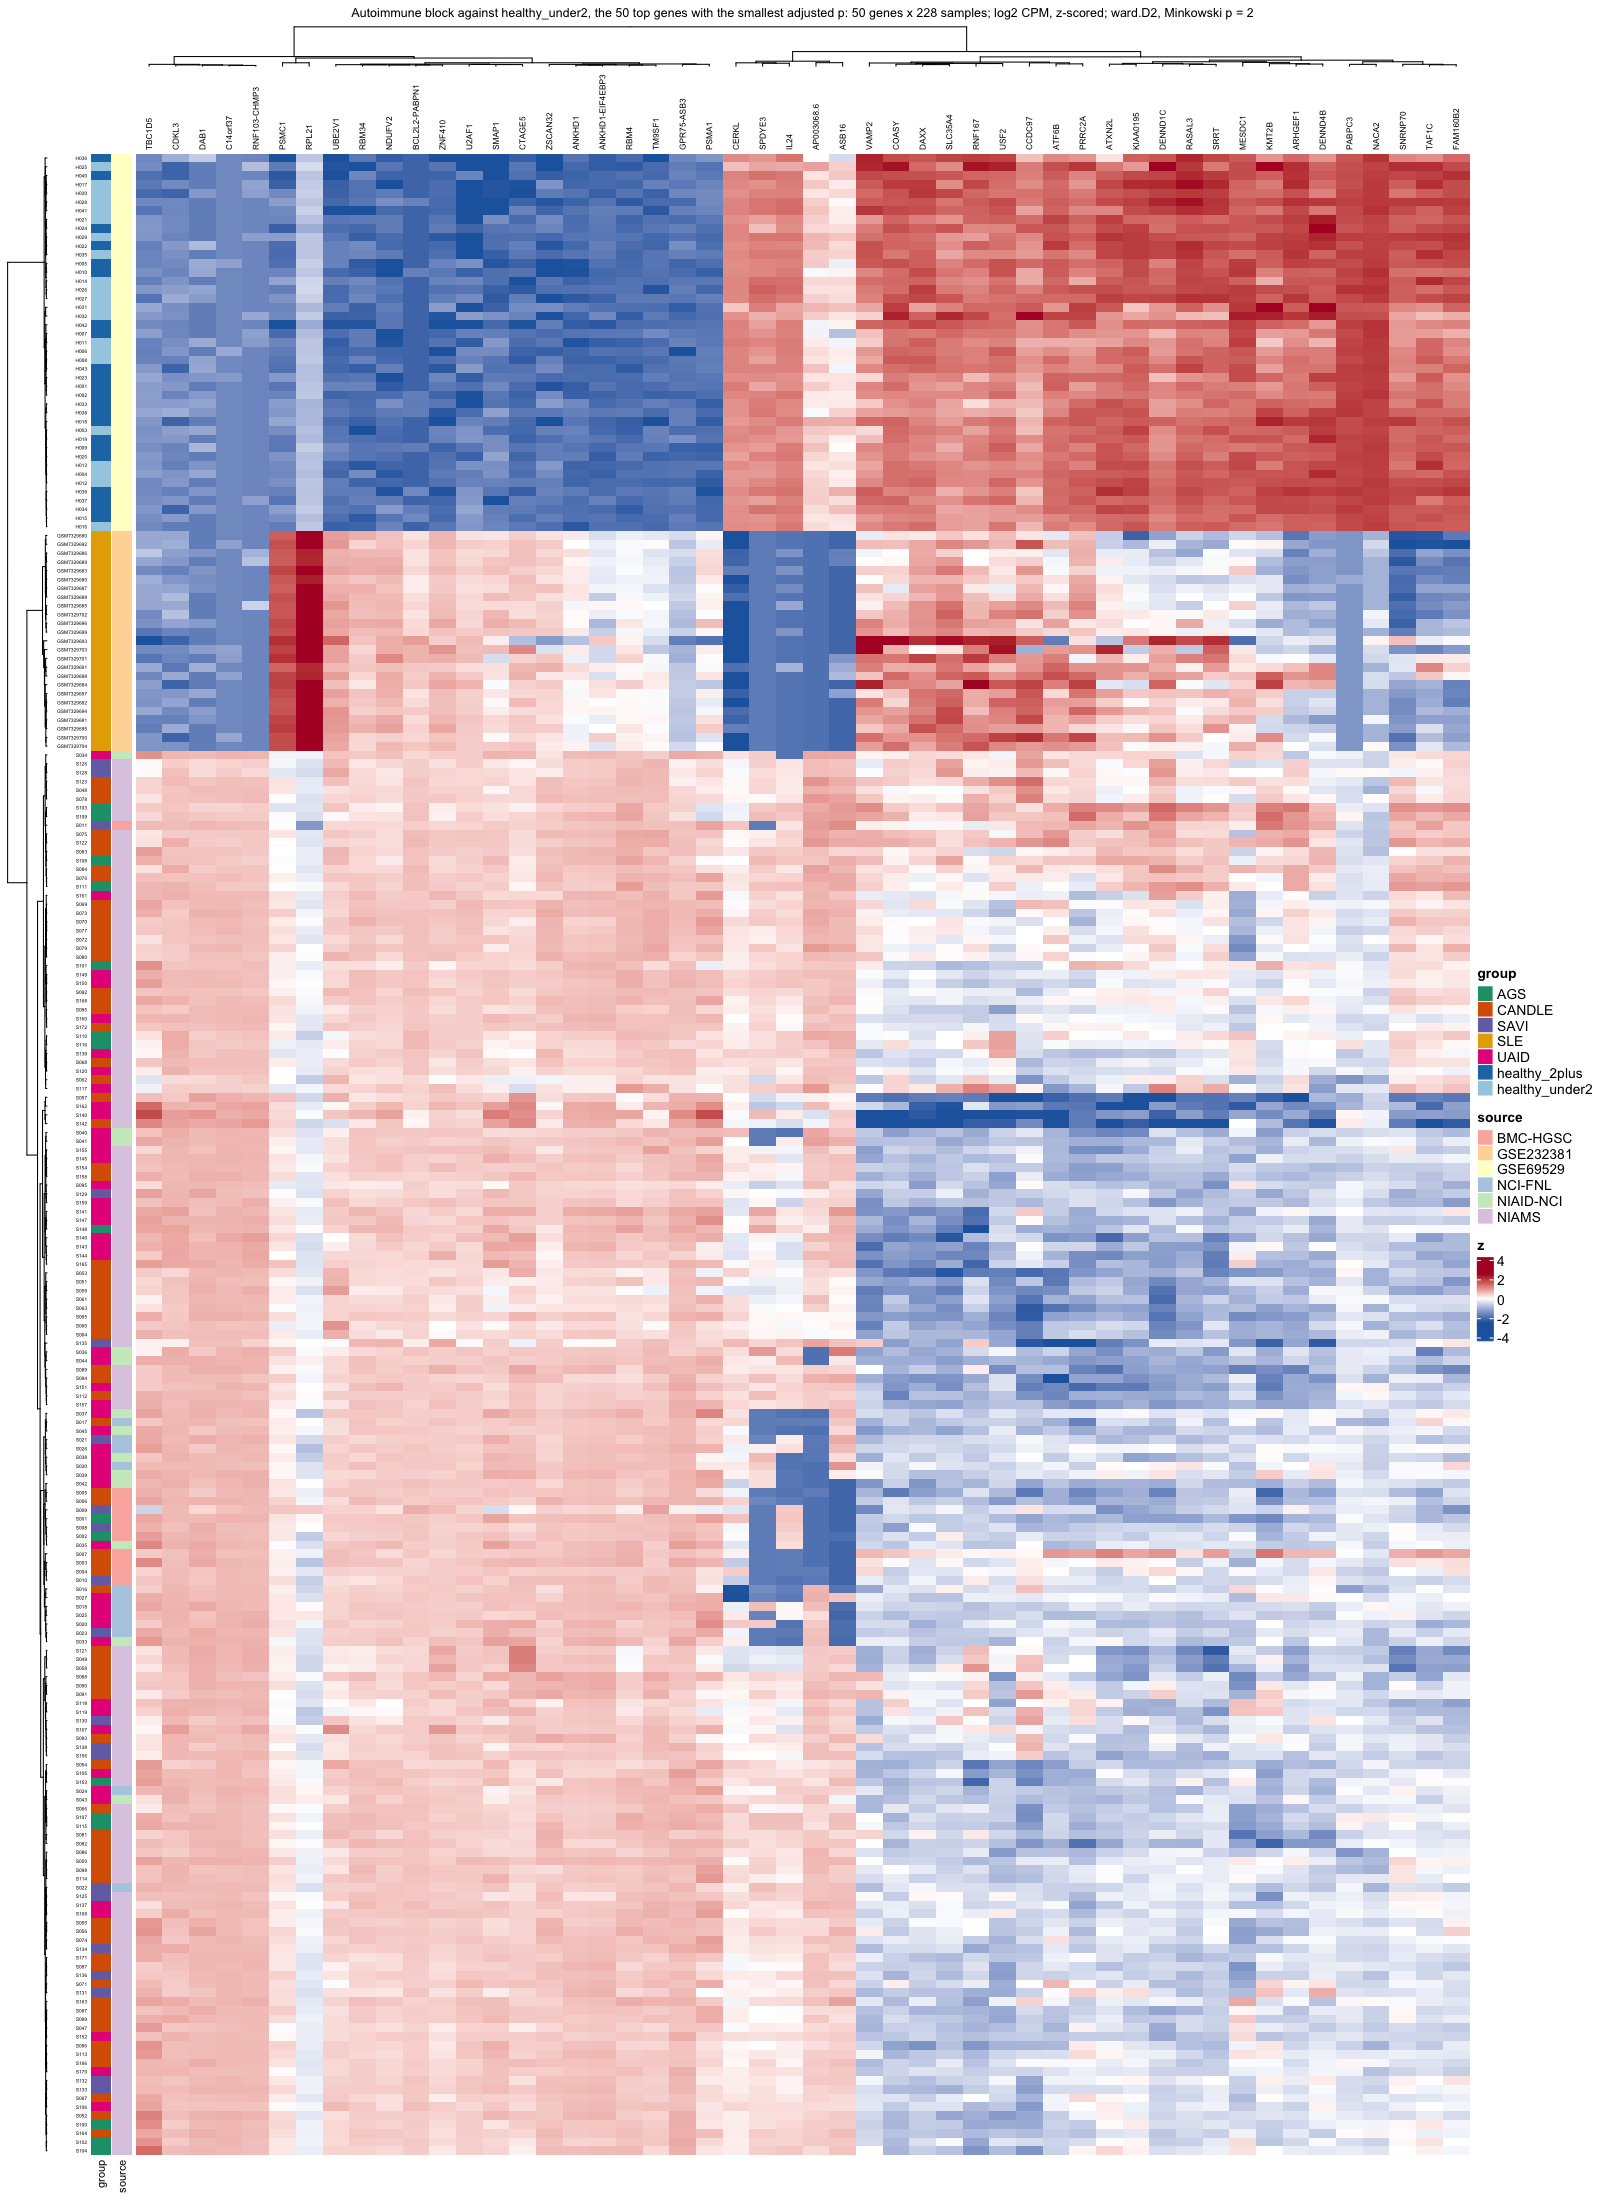

`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



saved, not shown: 46_heatmap_autoimmune_vs_healthy_under2.png (575 x 22 inches) 


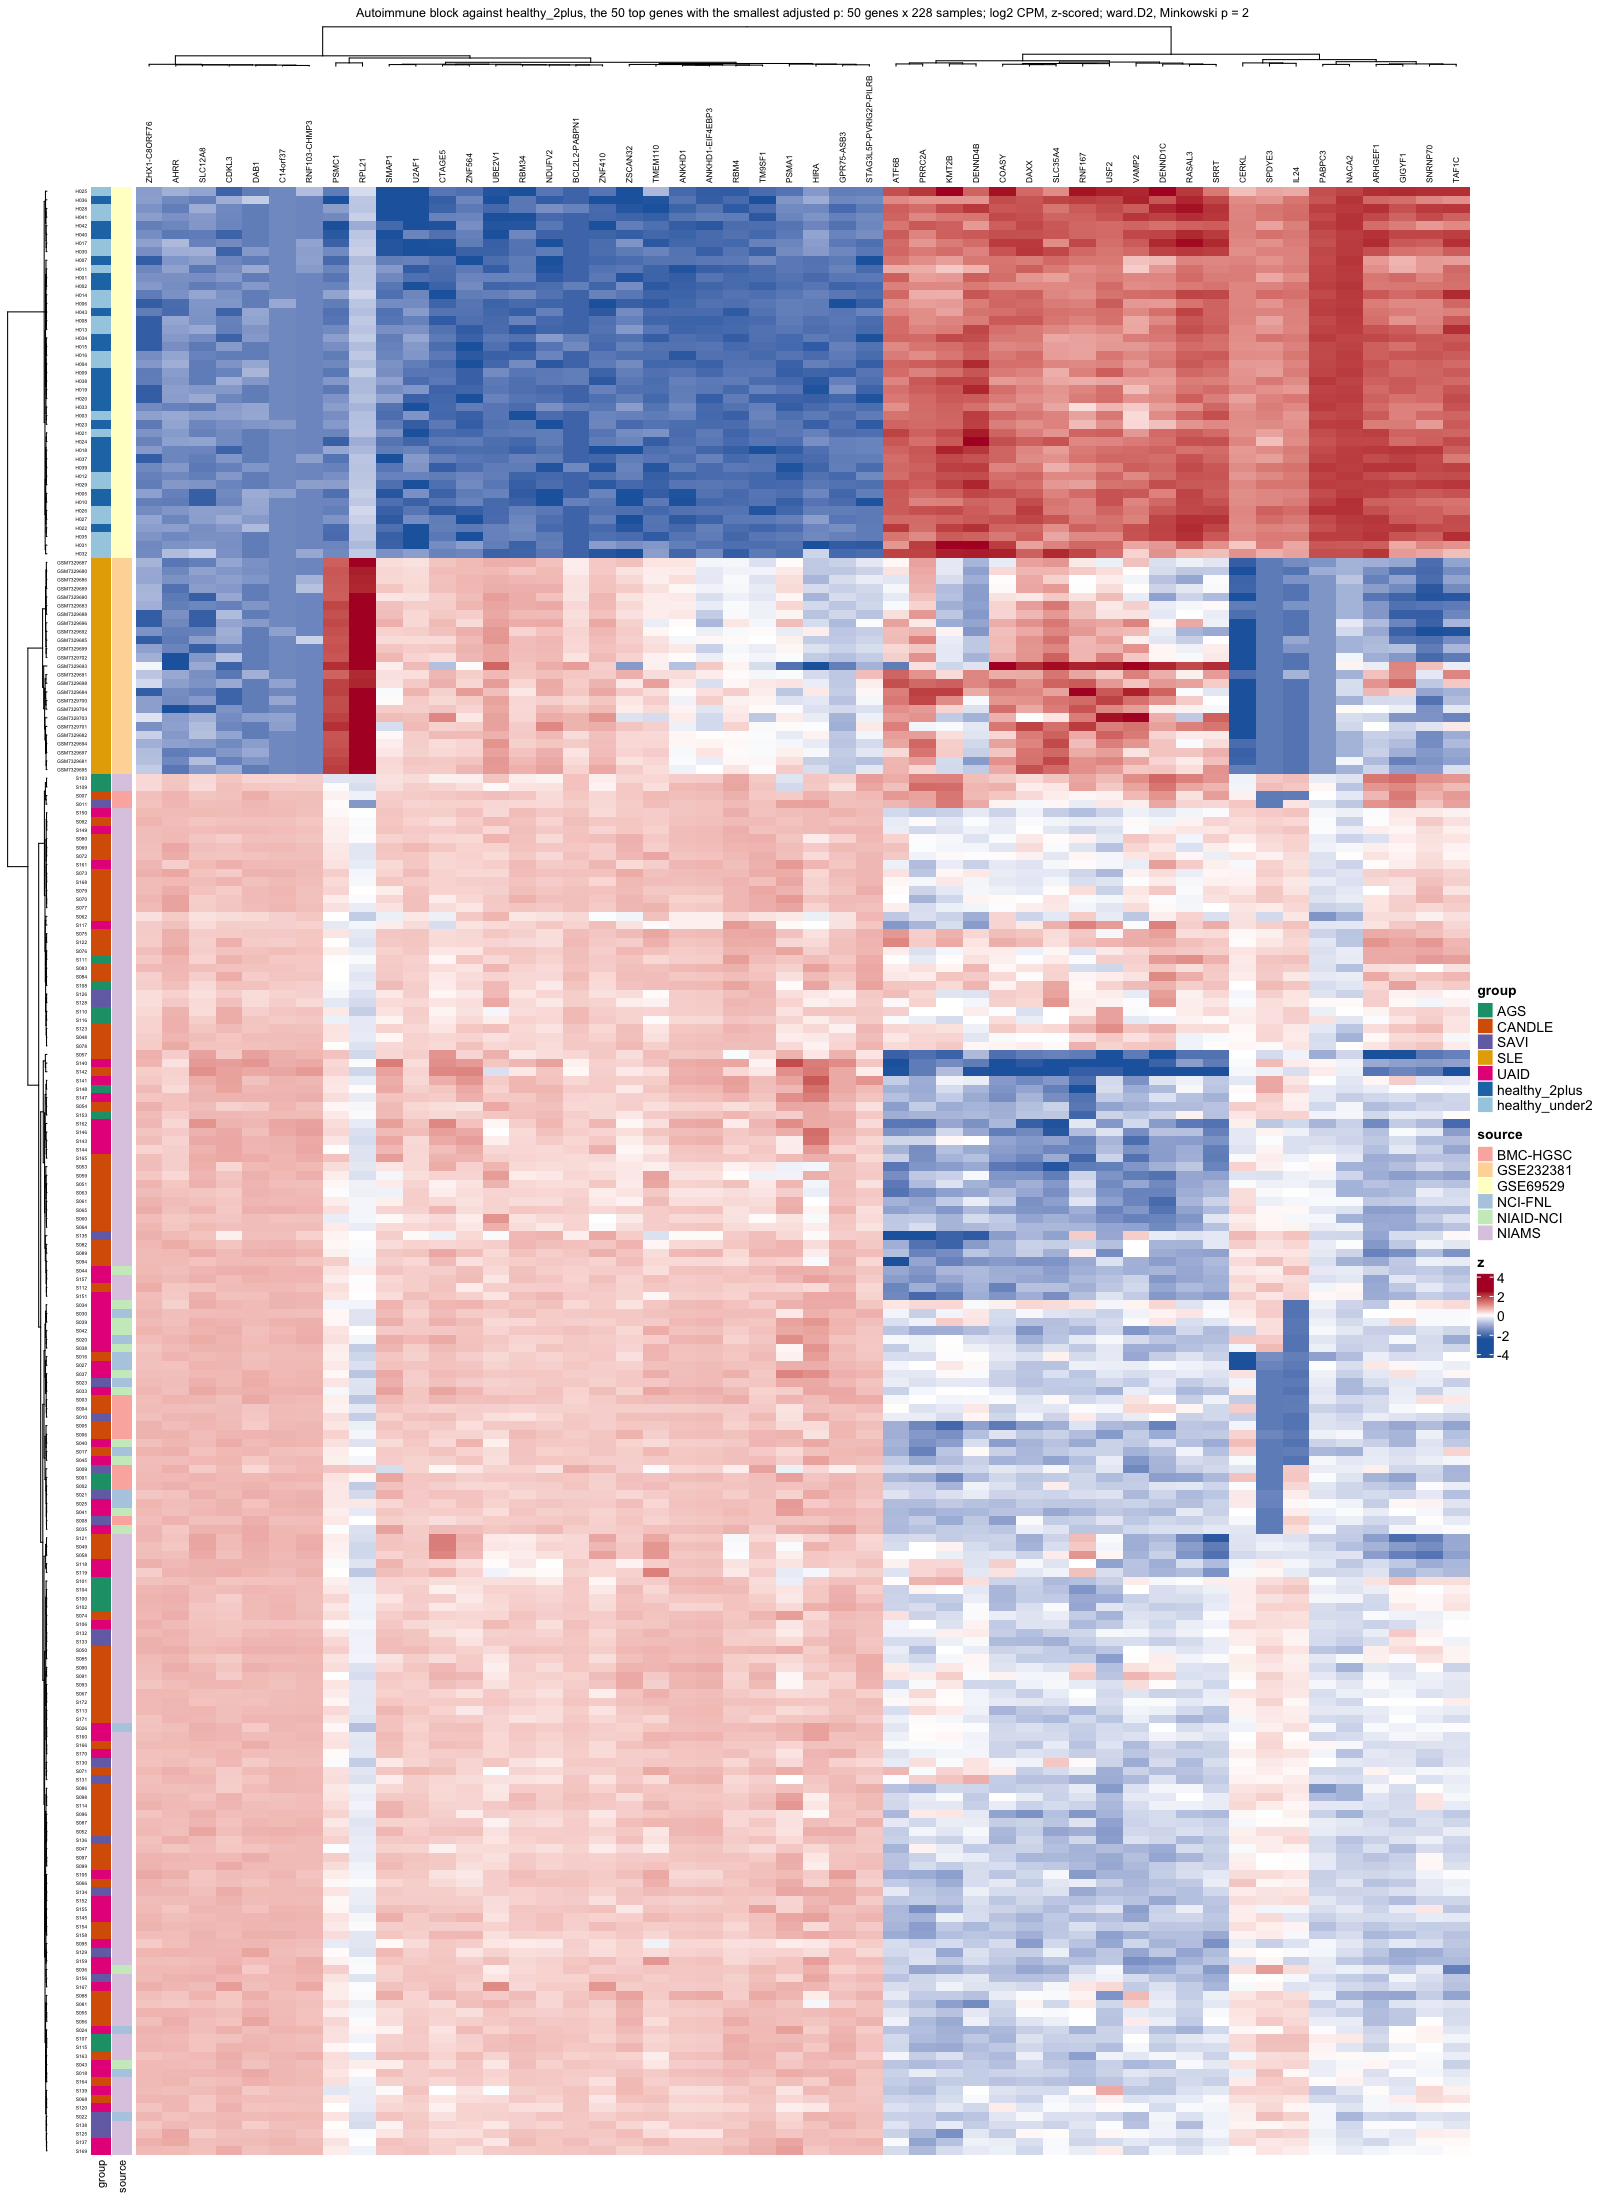

`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



saved, not shown: 46_heatmap_autoimmune_vs_healthy_2plus.png (564 x 22 inches) 


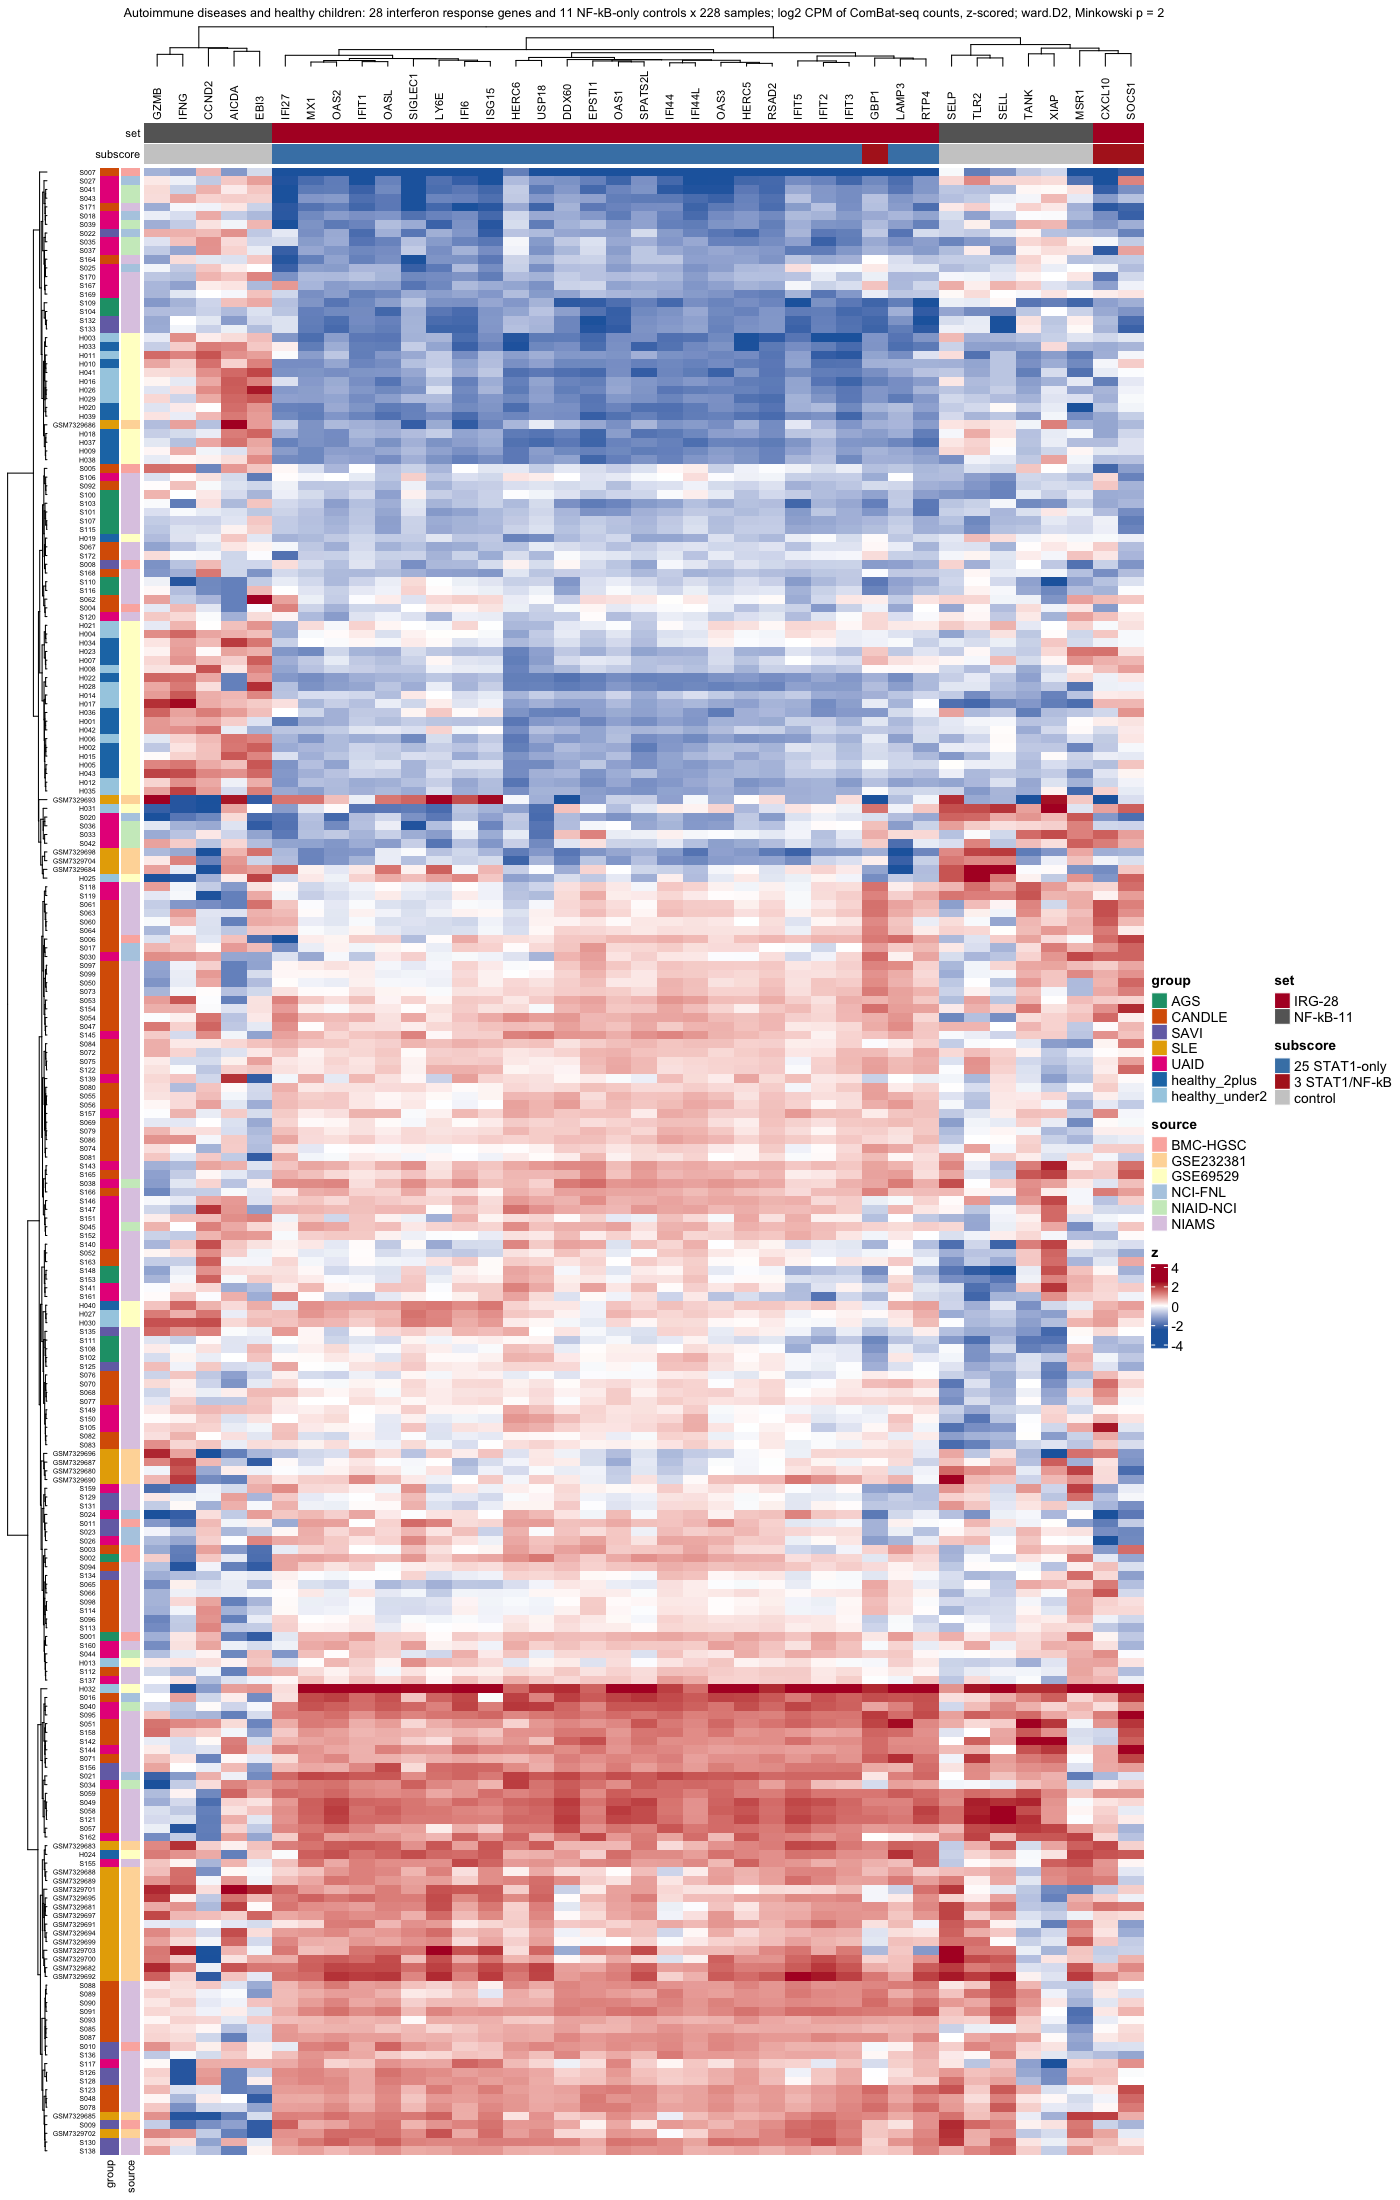

      group
branch AGS CANDLE SAVI UAID SLE healthy_under2 healthy_2plus
     1   7     65   16   32  20              4             2
     2   9     10    4   17   5             17            20

In [9]:
xc  <- readRDS(art("CANDLE_SAVI", "counts_combatseq.rds"))
disp <- cbind(round(xc$counts[genes, s$sample]), sle_counts[genes, ], hc[genes, hs$sample])[rownames(dge), ]
logcpm <- cpm(calcNormFactors(DGEList(disp)), log = TRUE)
grp_col <- c(AGS = "#1B9E77", CANDLE = "#D95F02", SAVI = "#7570B3", UAID = "#E7298A", SLE = "#E6AB02",
             healthy_under2 = "#A6CEE3", healthy_2plus = "#1F78B4")
src_col <- c("BMC-HGSC" = "#FBB4AE", "NCI-FNL" = "#B3CDE3", "NIAID-NCI" = "#CCEBC5", NIAMS = "#DECBE4",
             GSE232381 = "#FED9A6", GSE69529 = "#FFFFCC")
left <- rowAnnotation(group = as.character(meta$group), source = meta$facility,
                      col = list(group = grp_col, source = src_col), annotation_name_gp = gpar(fontsize = 8))
show_and_save <- function(ht, file, w, h, show = TRUE) {
  for (res in if (show) c(300, 100) else 300) {
    f <- if (res == 300) fig("CANDLE_SAVI", file) else tempfile(fileext = ".png")
    png(f, width = w, height = h, units = "in", res = res); draw(ht); invisible(dev.off())
  }
  if (show) IRdisplay::display_png(file = f) else cat("saved, not shown:", file, sprintf("(%.0f x %.0f inches)", w, h), "\n")
}
heat <- function(g, title) {
  H  <- scale(t(logcpm[g$gene_id, , drop = FALSE])); H <- H[, colSums(is.na(H)) == 0, drop = FALSE]
  Hc <- pmin(pmax(H, -2.5), 2.5)
  hr <- hclust(dist(H, method = "minkowski", p = 2), method = "ward.D2")
  hcl <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
  Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
          cluster_rows = hr, cluster_columns = hcl, row_dend_side = "left", column_dend_side = "top",
          row_names_side = "left", row_names_gp = gpar(fontsize = 3.5), column_names_side = "top",
          column_labels = g$gene_name[match(colnames(H), g$gene_id)], column_names_gp = gpar(fontsize = 6),
          left_annotation = left, column_title_gp = gpar(fontsize = 9),
          column_title = sprintf("%s: %d genes x %d samples; log2 CPM, z-scored; ward.D2, Minkowski p = 2", title, ncol(H), nrow(H)))
}
for (h in c("healthy_under2", "healthy_2plus")) {
  tg <- top[[paste0("autoimmune_vs_", h)]]
  show_and_save(heat(head(tg, 50), sprintf("Autoimmune block against %s, the 50 top genes with the smallest adjusted p", h)),
                sprintf("46_heatmap_autoimmune_vs_%s_top50.png", h), 16, 22)
  show_and_save(heat(tg, sprintf("Autoimmune block against %s, all top genes", h)), sprintf("46_heatmap_autoimmune_vs_%s.png", h),
                max(16, 4 + 0.07 * nrow(tg)), 22, show = FALSE)
}
r <- ifn_heat(logcpm[ifn$gene_id[!is.na(ifn$gene_id)], ], left, "Autoimmune diseases and healthy children")
show_and_save(r$ht, "46_interferon_heatmap.png", 14, 22)
table(branch = cutree(r$rows, 2), group = meta$group)

**Explanation**
- For display, the internal samples use the ComBat-seq counts of notebook 40 (corrected for the internal
  batches); the SLE and healthy samples use their counts as above. `logcpm` holds log2 counts per million after
  TMM normalization, for the genes kept above.
- `left` shows each sample's group and source; samples are named by code (internal `S`, healthy `H`) or GEO
  accession (SLE).
- `heat()` draws a heatmap as in notebook 42: samples as rows, genes as columns, z-scored per gene, Ward trees on
  both axes, sample codes and gene names next to their trees.
- For each healthy block, the 50 top genes of the autoimmune block with the smallest adjusted p are shown; the
  heatmap of all its top genes is saved.
- `ifn_heat()` draws the 28 interferon response genes and the 11 controls over all samples, as in notebook 42;
  `cutree(r$rows, 2)` gives the first split of the sample tree, crossed with group.

**Result.** The heatmaps of all top genes are saved (564 and 575 inches wide, about 8,000 genes); the notebook shows
the 50 top genes of each. In the interferon heatmap the first split of the sample tree puts 65 of 75 CANDLE, 16 of
20 SAVI, 32 of 49 UAID, 20 of 25 SLE and 7 of 16 AGS samples on one branch with 6 of the 43 healthy children, and
the other 37 healthy children with the remaining disease samples.

## Save for notebook 46b

In [10]:
saveRDS(list(meta = meta, logcpm = logcpm, genes = GENES, top = lapply(top, `[[`, "gene_id"), ifn = ifn),
        art("CANDLE_SAVI", "autoimmune_vs_healthy.rds"))
dim(logcpm)

[1] 14487   228

**Explanation**
- `autoimmune_vs_healthy.rds` keeps the sample table, the display values (log2 counts per million), the gene
  names, the top genes of each comparison and the interferon gene table, for notebook 46b.

## References

1. Law CW, Chen Y, Shi W, Smyth GK. voom: precision weights unlock linear model analysis tools for RNA-seq read counts. *Genome Biol* 2014;15:R29.
2. Ritchie ME, Phipson B, Wu D, Hu Y, Law CW, Shi W, Smyth GK. limma powers differential expression analyses for RNA-sequencing and microarray studies. *Nucleic Acids Res* 2015;43:e47.
3. Smyth GK, Michaud J, Scott HS. Use of within-array replicate spots for assessing differential expression in microarray experiments. *Bioinformatics* 2005;21:2067-2075.
4. Smyth GK. Linear models and empirical Bayes methods for assessing differential expression in microarray experiments. *Stat Appl Genet Mol Biol* 2004;3:Article3.
5. Benjamini Y, Hochberg Y. Controlling the false discovery rate: a practical and powerful approach to multiple testing. *J R Stat Soc B* 1995;57:289-300.
6. Robinson MD, McCarthy DJ, Smyth GK. edgeR: a Bioconductor package for differential expression analysis of digital gene expression data. *Bioinformatics* 2010;26:139-140.
7. Robinson MD, Oshlack A. A scaling normalization method for differential expression analysis of RNA-seq data. *Genome Biol* 2010;11:R25.
8. Chen Y, Lun ATL, Smyth GK. From reads to genes to pathways: differential expression analysis of RNA-Seq experiments using Rsubread and the edgeR quasi-likelihood pipeline. *F1000Research* 2016;5:1438.
9. Brown GR, Hem V, Katz KS, et al. Gene: a gene-centered information resource at NCBI. *Nucleic Acids Res* 2015;43:D36-D42.
10. Zhang Y, Parmigiani G, Johnson WE. ComBat-seq: batch effect adjustment for RNA-seq count data. *NAR Genom Bioinform* 2020;2:lqaa078.
11. Gu Z, Eils R, Schlesner M. Complex heatmaps reveal patterns and correlations in multidimensional genomic data. *Bioinformatics* 2016;32:2847-2849.
12. Gu Z, Gu L, Eils R, Schlesner M, Brors B. circlize implements and enhances circular visualization in R. *Bioinformatics* 2014;30:2811-2812.
13. Ward JH. Hierarchical grouping to optimize an objective function. *J Am Stat Assoc* 1963;58:236-244.
14. Murtagh F, Legendre P. Ward's hierarchical agglomerative clustering method: which algorithms implement Ward's criterion? *J Classif* 2014;31:274-295.
15. Kim H, et al. Development of a validated interferon score using NanoString technology. *J Interferon Cytokine Res* 2018;38:171-185.
16. de Jesus AA, et al. Distinct interferon signatures and cytokine patterns define additional systemic autoinflammatory diseases. *J Clin Invest* 2020;130:1669-1682.
17. Chen YC, et al. Peripheral blood cells RNA-seq identifies differentially expressed gene network linked to lymphocyte subsets alterations and active lupus nephritis associated with declines in renal function. *Heliyon* 2024;10:e32303.
18. DeBerg HA, et al. Shared and organism-specific host responses to childhood diarrheal diseases revealed by whole blood transcript profiling. *PLoS One* 2018;13:e0192082.